In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [29]:

def f_test(t, y):
    return -2 * t * y**2

def dfdy_test(t, y):          
    return -4 * t * y

def y_exact(t):
    return 1 / (1 + np.array(t, dtype=float)**2)

In [31]:
def newton(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    for k in range(1, max_iter + 1):
        x_new = x - f(x)/df(x)
        if abs(x_new - x) < tol:
            return x_new, k
        x = x_new
        
    return x, max_iter
    
# Problem 1(a)
def euler(f, t0, y0, h, n, method='forward', dfdy=None):
    t = t0 + h * np.arange(n+1)
    y = np.zeros(n+1)
    y[0] = y0

    for k in range(n):
        y_fwd = y[k] + h * f(t[k], y[k])

        if method == 'forward':
            y[k+1] = y_fwd
        elif method == 'backward':
            g = lambda z: z - y[k] - h * f(t[k+1], z)
            dg = lambda z: 1 - h * dfdy(t[k+1], z)
            y[k+1], _ = newton(g, dg, y_fwd)
        

    return t, y

f_cubic = lambda t, y: -y**3
dfdy_cubic = lambda t, y: -3*y**2

_, y_fe = euler(f_cubic, 0, 1, 0.5, 1, method='forward')
_, y_be = euler(f_cubic, 0, 1, 0.5, 1, method='backward', dfdy=dfdy_cubic)

print(f"Forward Euler  y1 = {y_fe[1]:.6f}")
print(f"Backward Euler y1 = {y_be[1]:.6f}")
print(f"Exact      y(0.5) = {1/np.sqrt(2):.6f}")

Forward Euler  y1 = 0.500000
Backward Euler y1 = 0.770917
Exact      y(0.5) = 0.707107


In [33]:
# Problem 1(b)
def rk2(f, t0, y0, h, n):
    t = t0 + h * np.arange(n + 1)
    y = np.zeros(n + 1)
    y[0] = y0

    for k in range(n):
        k1 = h * f(t[k], y[k])
        k2 = h * f(t[k + 1], y[k] + k1)

        y[k+1] = y[k] + 0.5*(k1 + k2)
    


    return t, y


t_rk2, y_rk2 = rk2(f_test, 0, 1, 0.25, 2)
print(f"RK2: y1 = {y_rk2[1]:.4f}, y2 = {y_rk2[2]:.4f}")

RK2: y1 = 0.9375, y2 = 0.7969


In [36]:
# Problem 1(c)
def rk4(f, t0, y0, h, n):
    t = t0 + h * np.arange(n + 1)
    y = np.zeros(n + 1)
    y[0] = y0

    for k in range(n):
        k1 = h * f(t[k], y[k])
        k2 = h * f(t[k] + h/2, y[k] + k1/2)
        k3 = h * f(t[k] + h/2, y[k] + k2/2)
        k4 = h * f(t[k] + h, y[k] + k3)
    
        y[k+1] = y[k] + (k1 + 2*k2 + 2*k3 + k4)/6


    return t, y


t_rk4, y_rk4 = rk4(f_test, 0, 1, 0.25, 2)

print(f"{'k':<3} | {'t_k':<6} | {'RK2':<10} | {'RK4':<10} | {'Exact':<10}")
print("-" * 50)
for k in range(3):
    print(f"{k:<3} | {t_rk4[k]:<6.2f} | {y_rk2[k]:<10.6f} | {y_rk4[k]:<10.6f} | {y_exact(t_rk4[k]):<10.6f}")


k   | t_k    | RK2        | RK4        | Exact     
--------------------------------------------------
0   | 0.00   | 1.000000   | 1.000000   | 1.000000  
1   | 0.25   | 0.937500   | 0.941154   | 0.941176  
2   | 0.50   | 0.796946   | 0.799948   | 0.800000  


In [38]:
# Problem 1(d)
def multistep2(f, t0, y0, h, n):
    t = t0 + h * np.arange(n + 1)
    y = np.zeros(n + 1)
    y[0] = y0

    _, y_start = rk2(f, t0, y0, h, 1)
    y[1] = y_start[1]

    for k in range(1, n):
        y[k+1] = y[k] + h/2 * (3*f(t[k], y[k]) - f(t[k - 1], y[k - 1]))

    return t, y

_, y_ms2 = multistep2(f_test, 0, 1, 0.25, 2)
print(f"2-step method: y1 = {y_ms2[1]:.4f}, y2 = {y_ms2[2]:.4f}")

2-step method: y1 = 0.9375, y2 = 0.7727


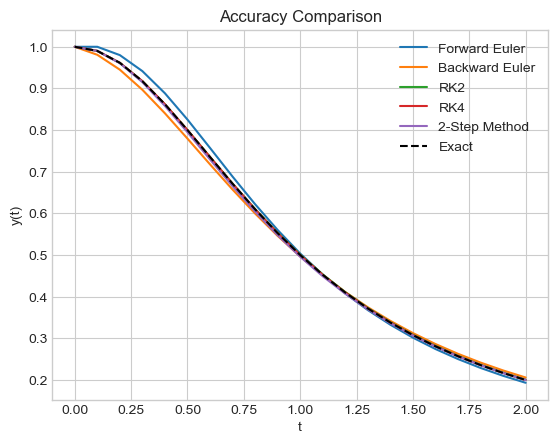

Absolute errors at t = 2:
Forward Euler: 0.006658
Backward Euler: 0.005978
RK2: 0.000695
2-Step Method: 0.000048
RK4: 0.000001


In [40]:
# Problem 1(e)[i]
h, T = 0.1, 2.0
n = int(round(T / h))
t, y_fe = euler(f_test, 0, 1, h, n, method='forward')
_, y_be = euler(f_test, 0, 1, h, n, method='backward', dfdy=dfdy_test)
_, y_rk2 = rk2(f_test, 0, 1, h, n)
_, y_rk4 = rk4(f_test, 0, 1, h, n)
_, y_ms2 = multistep2(f_test, 0, 1, h, n)

y_ex = y_exact(t)

plt.plot(t, y_fe, label='Forward Euler')
plt.plot(t, y_be, label='Backward Euler')
plt.plot(t, y_rk2, label='RK2')
plt.plot(t, y_rk4, label='RK4')
plt.plot(t, y_ms2, label='2-Step Method')
plt.plot(t, y_ex, 'k--', label='Exact')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Accuracy Comparison')
plt.legend()
plt.show()

errors = [
    ('Forward Euler', abs(y_fe[-1] - y_ex[-1])),
    ('Backward Euler', abs(y_be[-1] - y_ex[-1])),
    ('RK2', abs(y_rk2[-1] - y_ex[-1])),
    ('RK4', abs(y_rk4[-1] - y_ex[-1])),
    ('2-Step Method', abs(y_ms2[-1] - y_ex[-1]))
]
errors.sort(key=lambda x: x[1], reverse=True)
print("Absolute errors at t = 2:")
for method, error in errors:
    print(f"{method}: {error:.6f}")

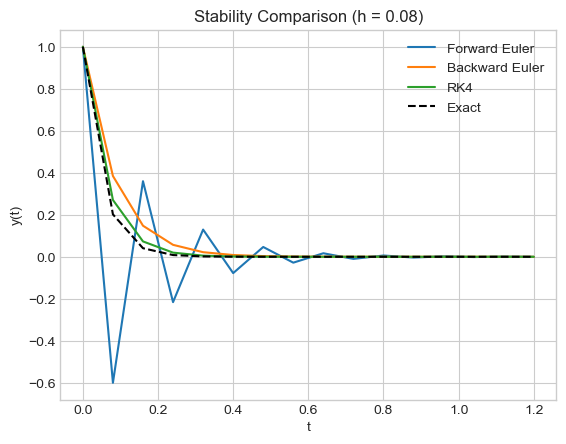

h = 0.08
Forward Euler growth factor = 0.6000
Backward Euler growth factor = 0.3846


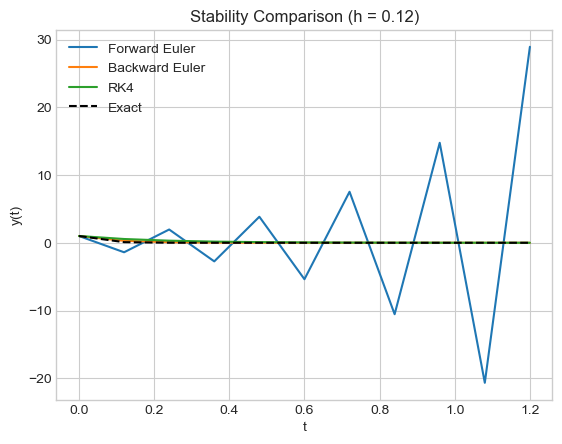

h = 0.12
Forward Euler growth factor = 1.4000
Backward Euler growth factor = 0.2941


In [44]:
lam = -20.0
T = 1.2
def f_stability(t, y):
    return lam * y
def dfdy_stability(t, y):
    return lam
for h in [0.08, 0.12]:
    n = int(round(T/h))
    t, y_fe = euler(f_stability, 0, 1, h, n, method='forward')
    _, y_be = euler(f_stability, 0, 1, h, n, method='backward', dfdy=dfdy_stability)
    _, y_rk4 = rk4(f_stability, 0, 1, h, n)
    y_ex = np.exp(lam * t)

    plt.plot(t, y_fe, label='Forward Euler')
    plt.plot(t, y_be, label='Backward Euler')
    plt.plot(t, y_rk4, label='RK4')
    plt.plot(t, y_ex, 'k--', label='Exact')
    plt.xlabel('t')
    plt.ylabel('y(t)')
    plt.title(f'Stability Comparison (h = {h})')
    plt.legend()
    plt.show()

    forward_growth = abs(1 + h*lam)
    backward_growth = abs(1 / (1 - h*lam))

    print(f"h = {h}")
    print(f"Forward Euler growth factor = {forward_growth:.4f}")
    print(f"Backward Euler growth factor = {backward_growth:.4f}")

In [46]:
# Problem 2(a)
def adams_bashforth4(f, t0, y0, h, n):
    t = t0 + h * np.arange(n + 1)
    y = np.zeros(n + 1)

    _, y_start = rk4(f, t0, y0, h, 3)
    y[:4] = y_start

    for k in range(3, n):
        fk = f(t[k], y[k])
        fk1 = f(t[k-1], y[k-1])
        fk2 = f(t[k-2], y[k-2])
        fk3 = f(t[k-3], y[k-3])

        y[k+1] = y[k] + (h/24)*(55*fk - 59*fk1 + 37*fk2 - 9*fk3) 

    return t, y

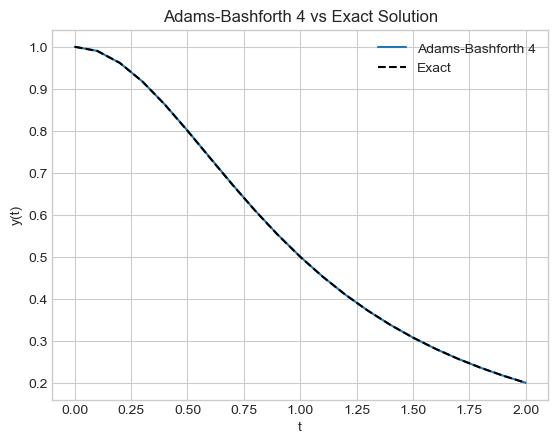

Absolute errors at t = 2:
Adams-Bashforth 4: 0.000019
RK4: 0.000001
2-Step Method: 0.000048


In [48]:
# Problem 2(b)
h, T = 0.1, 2.0
n = int(round(T / h))

t, y_ab4 = adams_bashforth4(f_test, 0, 1, h, n)
_, y_rk4 = rk4(f_test, 0, 1, h, n)
_, y_ms2 = multistep2(f_test, 0, 1, h, n)
y_ex = y_exact(t)

plt.plot(t, y_ab4, label='Adams-Bashforth 4')
plt.plot(t, y_ex, 'k--', label='Exact')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Adams-Bashforth 4 vs Exact Solution')
plt.legend()
plt.show()

error_ab4 = abs(y_ab4[-1] - y_ex[-1])
error_rk4 = abs(y_rk4[-1] - y_ex[-1])
error_ms2 = abs(y_ms2[-1] - y_ex[-1])
print("Absolute errors at t = 2:")
print(f"Adams-Bashforth 4: {error_ab4:.6f}")
print(f"RK4: {error_rk4:.6f}")
print(f"2-Step Method: {error_ms2:.6f}")

In [53]:
# Problem 3(a)
def adams_moulton4(f, t0, y0, h, n, tol=1e-10, max_iter=20):
    t = t0 + h * np.arange(n + 1)
    y = np.zeros(n + 1)
    iters = []

    _, y_start = rk4(f, t0, y0, h, 3)
    y[:4] = y_start

    for k in range(3, n):
        fk = f(t[k], y[k])
        fk1 = f(t[k-1], y[k-1])
        fk2 = f(t[k-2], y[k-2])
        fk3 = f(t[k-3], y[k-3])

        y_pred = y[k] + (h/24)*(55*fk - 59*fk1 + 37*fk2 - 9*fk3)

        for m in range(1, max_iter + 1):
            y_corr = y[k] + (h/24) * (9*f(t[k+1], y_pred) + 19*fk - 5*fk1 + fk2)

            converged = abs(y_corr - y_pred) < tol
            y_pred = y_corr
            if converged:
                break 
        y[k+1] = y_corr
        iters.append(m)
        
    return t, y, iters

Corrector iterations per step: [13, 12, 12, 11, 10]
Absolute errors at t = 2:
Adams-Bashforth 4: 0.014921
Single correction: 0.000786
Repeated correction: 0.000228


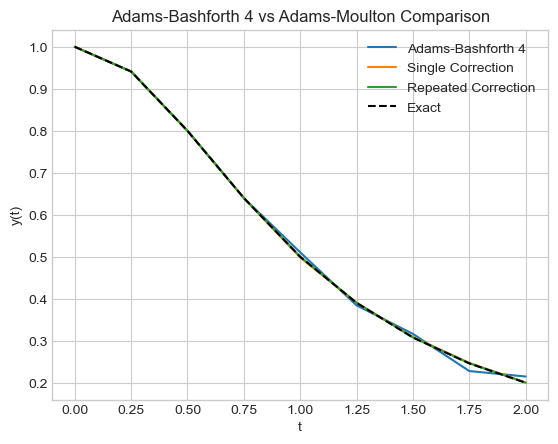

In [56]:
# Problem 3(b)
h, T = 0.25, 2.0
n = int(round(T / h))

t, y_ab4 = adams_bashforth4(f_test, 0, 1, h, n)
_, y_single, iters_single = adams_moulton4(f_test, 0, 1, h, n, max_iter=1)
_, y_repeat, iters_repeat = adams_moulton4(f_test, 0, 1, h, n)
y_ex = y_exact(t)

print("Corrector iterations per step:", iters_repeat)

error_ab4 = abs(y_ab4[-1] - y_ex[-1])
error_single = abs(y_single[-1] - y_ex[-1])
error_repeat = abs(y_repeat[-1] - y_ex[-1])

print("Absolute errors at t = 2:")
print(f"Adams-Bashforth 4: {error_ab4:.6f}")
print(f"Single correction: {error_single:.6f}")
print(f"Repeated correction: {error_repeat:.6f}")
plt.plot(t, y_ab4, label='Adams-Bashforth 4')
plt.plot(t, y_single, label='Single Correction')
plt.plot(t, y_repeat, label='Repeated Correction')
plt.plot(t, y_ex, 'k--', label='Exact')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Adams-Bashforth 4 vs Adams-Moulton Comparison')
plt.legend()
plt.show()